# Credit Card Fraud Detection Assessment

Credit card fraud costs people, banks, and businesses billions of dollars every year. In many cases, it may be extremely hard to detect fraud transactions since they may look very similar to legitimate transactions. 

In this assessment, we will train a machine learning model using the Kaggle credit card fraud dataset to learn patterns in past transactions and predict whether or not a transaction is legitimate or fraudulent. We will walk through the full pipeline:

1. **Data Exploration:** Understand the data
2. **Data Preprocessing:** Clean, scale, and split the data appropriately
3. **Customer Segmentation:** Cluster transactions into groups using K-Means clustering

In [9]:
# Install dependencies (Comment this out after running it once)
# !pip install kagglehub imbalanced-learn torch --quiet

Let's download the dataset from Kaggle:

In [10]:
import kagglehub
from pathlib import Path

path = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud")) / "creditcard.csv"

if path.exists():
    print("Dataset successfully downloaded")
else:
    print("Dataset not found")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset successfully downloaded


Now let's load the dataset into a Pandas DataFrame so we can further explore:

In [11]:
import numpy as np
import pandas as pd

df = pd.read_csv(path)

print(f"Shape: {df.shape} -> {df.shape[0]} transactions and {df.shape[1]} features\n")

df

Shape: (284807, 31) -> 284807 transactions and 31 features



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## Dataset Overview

- 284,807 transactions
- V1 - V28 are PCA-transformed features (already scaled and anonymous for privacy)
- Time is in seconds elapsed since the first transaction in the dataset (**needs scaling**)
- Amount is in Euros (**needs scaling**)
- Class: label `0` = legitimate, `1` = fraud

Since V1–V28 are already PCA-transformed, they are already standardized and doesn't need any further scaling. We only need to scale `Time` and `Amount` (after `train_test_split()` to prevent data leakage).

## 1. Data Exploration

Before touching the data, we need to understand it. Some questions we may ask ourselves are:
- Is the data clean? (Ex. Are there any missing values)
- What does the target distribution look like?
- What patterns separate fraudulent from legitimate transactions?

### 1.1 Missing Values

In [12]:
missing_table = df.isnull().sum()                           # Series
print(f"Total missing values: {missing_table.sum()}")

print("\nMissing values by columns:\n")
missing_table = missing_table.reset_index()                 # Reassign Series to a DataFrame
missing_table.columns = ["Column", "Missing Values"]

display(missing_table.style.hide(axis="index"))

Total missing values: 0

Missing values by columns:



Column,Missing Values
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Looks like there are no missing values in the dataset. Let's analyze the distribution further

### 1.2 Feature Distributions & Statistical Summary 

Before deciding how to scale our features, we need to understand the distribution. A histogram can give us a good idea of the distirbution across all the features:

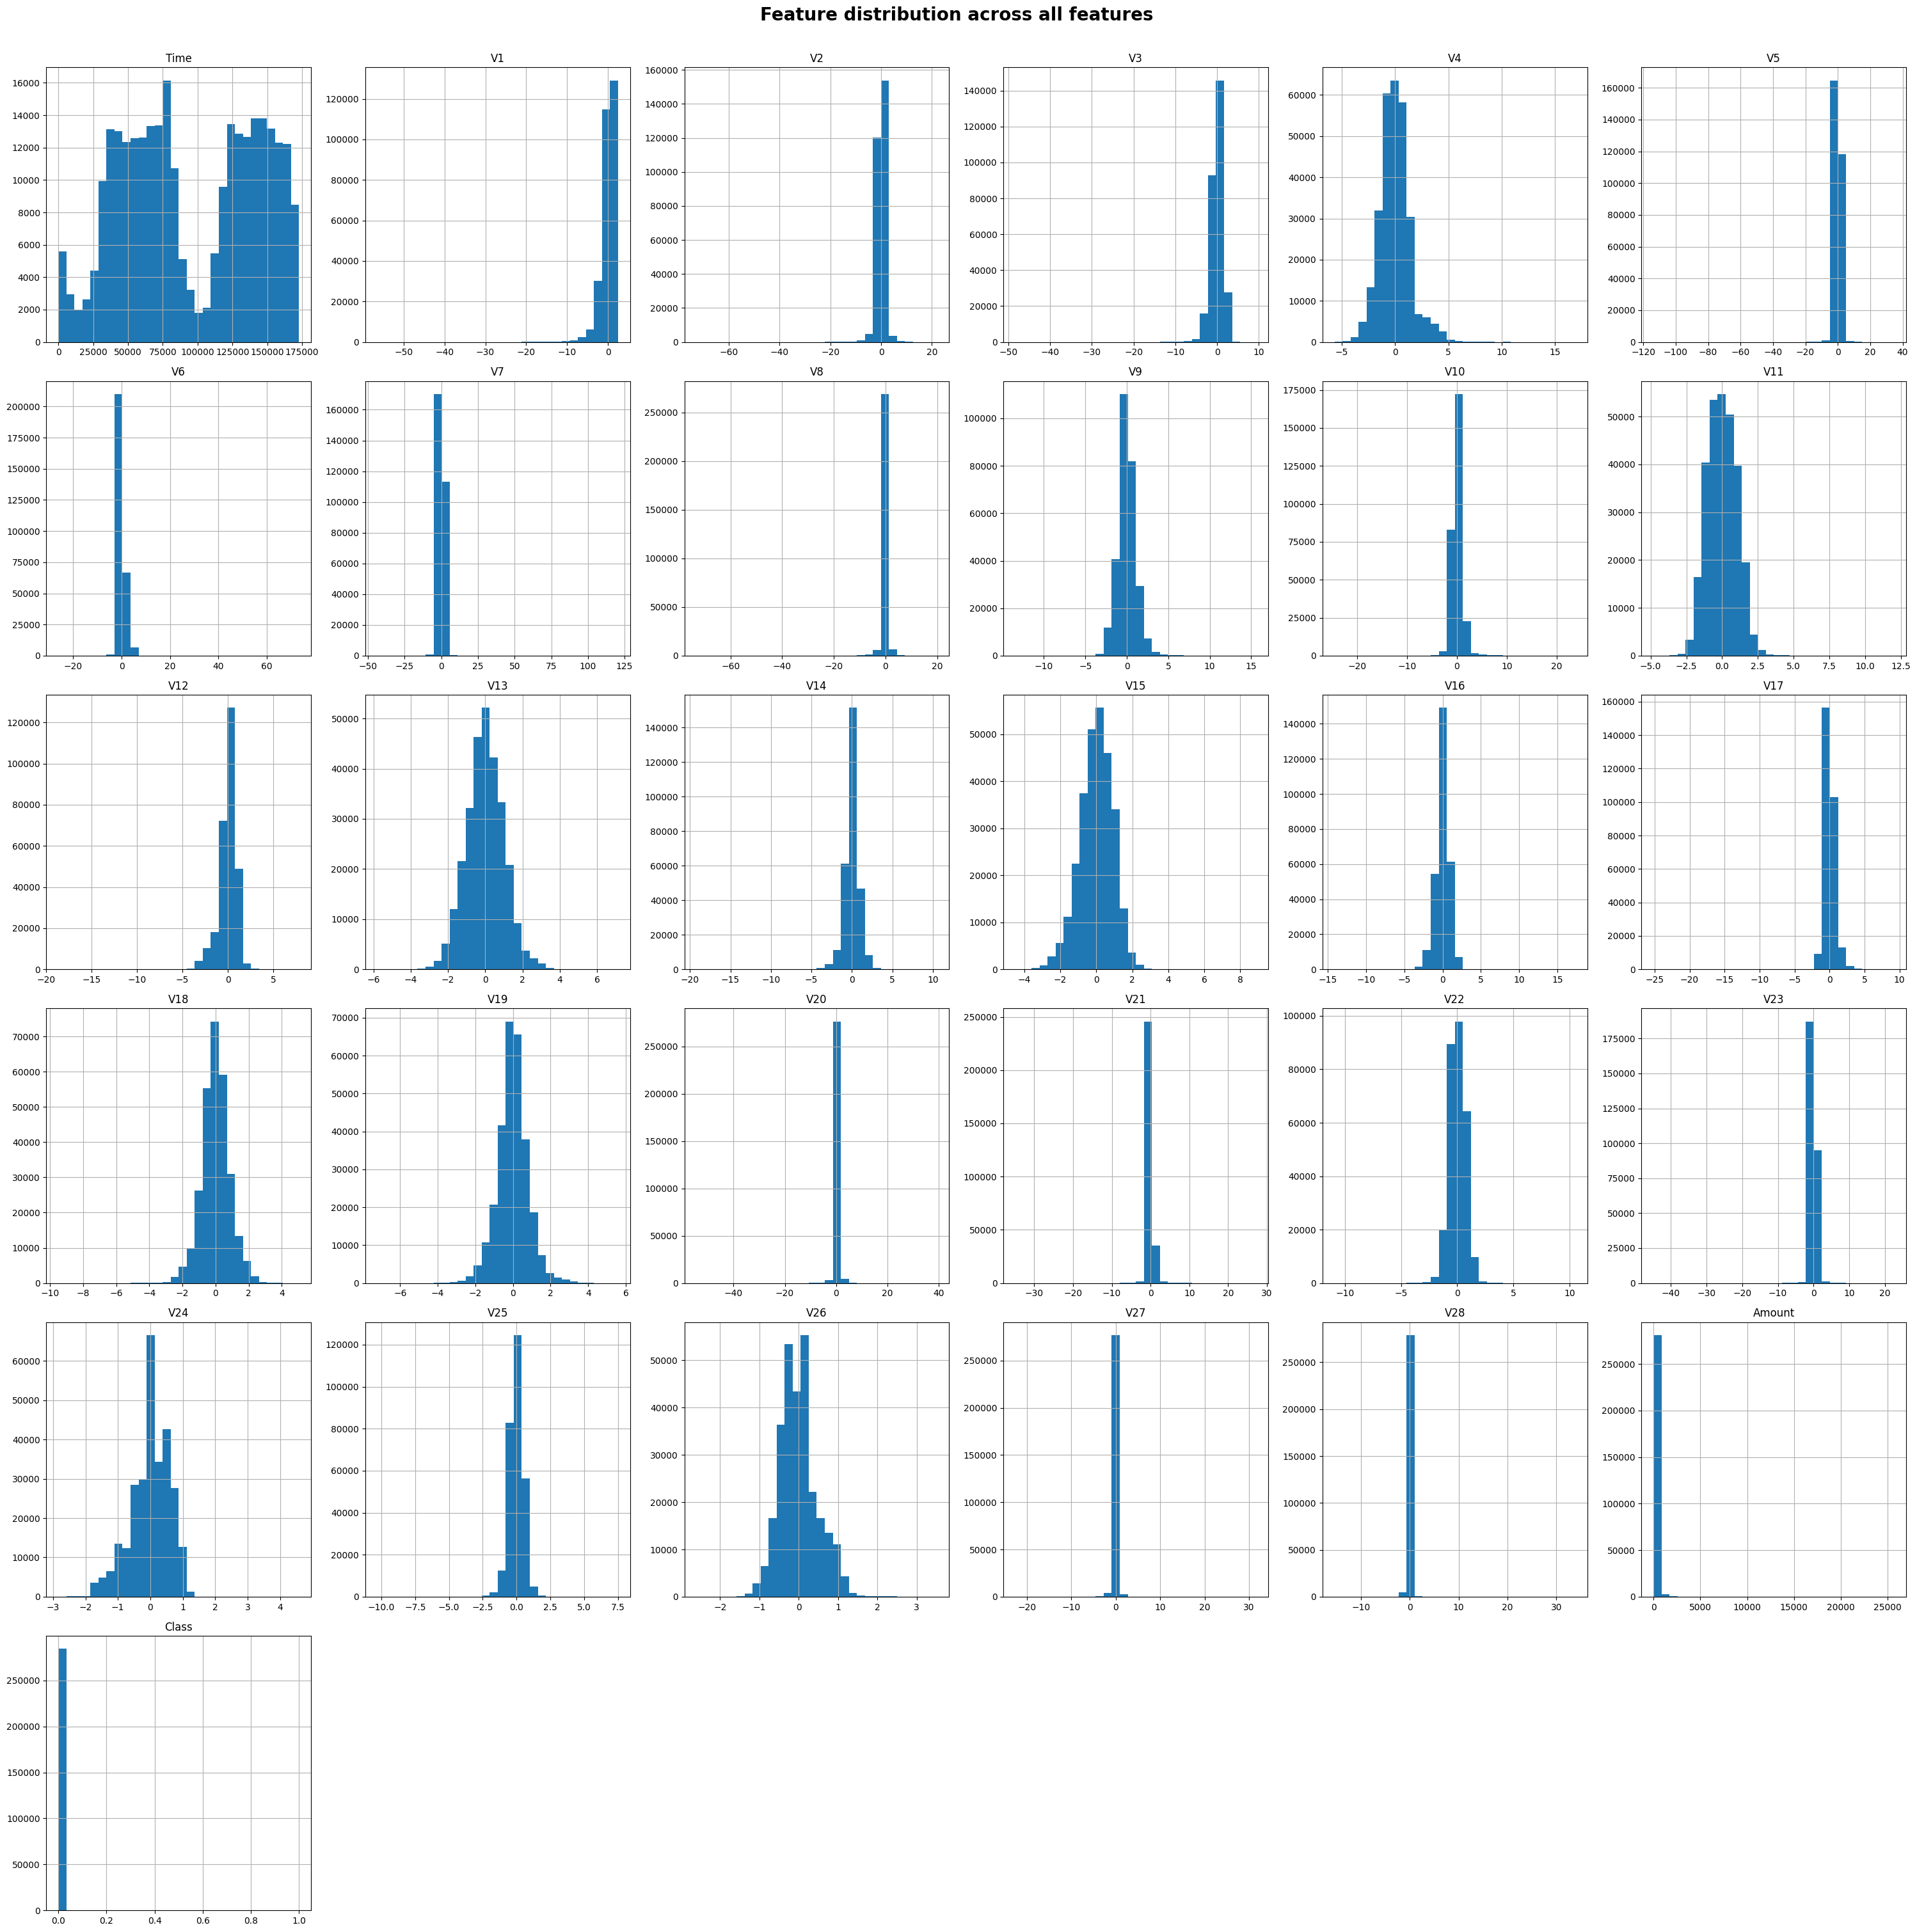

In [13]:
import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(30, 30))
plt.suptitle('Feature distribution across all features', fontweight='bold', fontsize=20, y=1.005)
# plt.savefig('plots/feature_distributions.png', dpi=200)
plt.tight_layout()
plt.show()

We can see that most of the histograms are almost normally distributed. However, `Amount` looks heavily imbalanced. Let's have a closer look with a log scale:

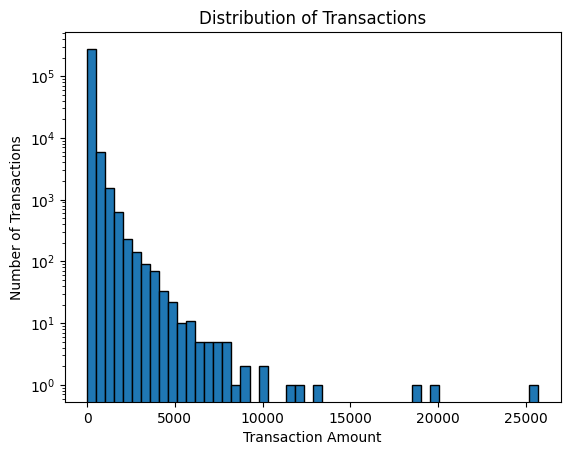

In [14]:
plt.hist(df['Amount'], bins=50, edgecolor='black')
plt.yscale("log")
plt.title("Distribution of Transactions")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
# plt.savefig('plots/amount_distribution_log_scale.png', dpi=200)
plt.show()

In [15]:
df[['Time', 'Amount', 'Class']].describe().round(2)

,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00


We notice:
- The overwhelming majority of transactions are under €500 with one transaction reaching past €25,000. 
- This extreme right skew means that the mean (€88.35) is the result of heavily influence by the large numbers. 
- The median (€22), however, tells gives a different story:
    - mean ($88) is 4x the median ($22) -> Outlier distortion
    - max ($25,691) is ~1168x the median ($22) -> Extreme right skew

This directly influences our scaling strategy. StandardScaler would be distorted by these extreme outliers for `Amount`. Therefore, RobustScaler is the better choice since ituses median + IQR instead, making it immune to outlier influence.

### 1.3 Class Distribution

Let's see how many transactions are fraudulent (1) vs legitimate (0):

In [16]:
class_counts = df["Class"].value_counts().reset_index()
class_counts.columns = ["Class", "Count"]
class_counts["Percentage (%)"] = ((class_counts["Count"] / class_counts["Count"].sum()) * 100)

display(class_counts.style.hide(axis="index"))

Class,Count,Percentage (%)
0,284315,99.827251
1,492,0.172749


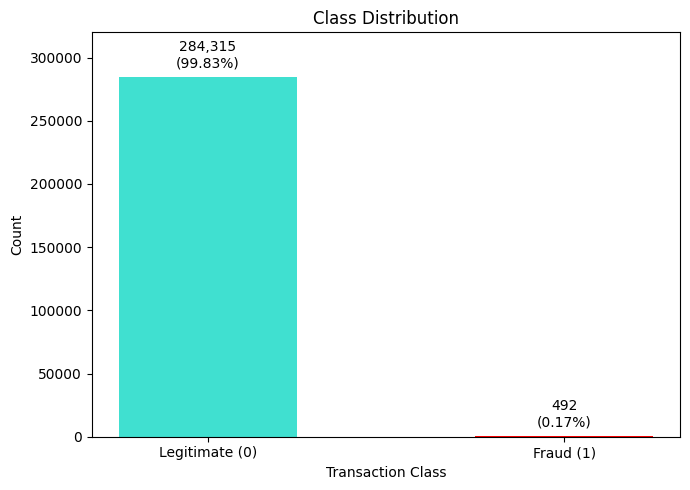

In [17]:
categories = ["Legitimate (0)", "Fraud (1)"]
values = [284315, 492]
percentages = [99.83, 0.17]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(categories, values, color=["turquoise", "red"], width=0.5)
labels = [f"{values[0]:,}\n({percentages[0]}%)", f"{values[1]:,}\n({percentages[1]}%)"]
ax.bar_label(bars, labels=labels, padding=5)
ax.set_title("Class Distribution")
ax.set_xlabel("Transaction Class")
ax.set_ylabel("Count")
ax.set_ylim(0, 320000)
# plt.savefig('plots/class_distribution.png', dpi=200)
plt.tight_layout()
plt.show()

- The imbalance is extreme: a 578:1 ratio of legitimate to fraud. 
- Accuracy is useless here: The data is so imbalanced that a model can score high just by igonring the fraud class entirely. 
    - Recall fixes this by looking at at the fraud cases. 
- As a result:
    1. We will use SMOTE to synthetically create data to balance the training data so that the model can see enough fraud to learn from.

### 1.4 Transaction Amount Distribution

Do fraudulent transactions differ significantly by amount? Let's try to visualize the density:

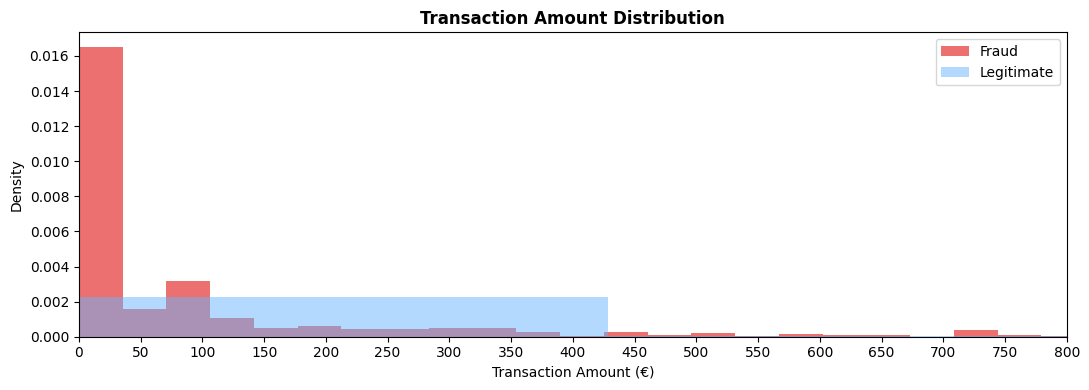

In [18]:
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(fraud, bins=60, alpha=0.8, color='#E84C4C', label='Fraud', density=True)
ax.hist(legit, bins=60, alpha=0.5, color="#69B4FF", label='Legitimate', density=True)
ax.set_xlim(0, 800)
ax.set_xticks(range(0, 801, 50))
ax.set_xlabel('Transaction Amount (€)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
# plt.savefig('plots/transaction_amount_distribution.png', dpi=150)
plt.show()

We notice a few things:
- We can see from the red spike from €0 – €50 that fraduluent transactions concentrate at low amounts. This is done on purpose to evade any red flags or signals.
- Legitimate transactions are more spread out.

### 1.5 Feature Correlations with Fraud

Using the correlation matrix, let's try to idenfity which features has the strongest correlation to fraud. Since V1–V28 are PCA components, we are identifying which principal components carry the most fraud signal. This will connect directly to our SHAP analysis later:

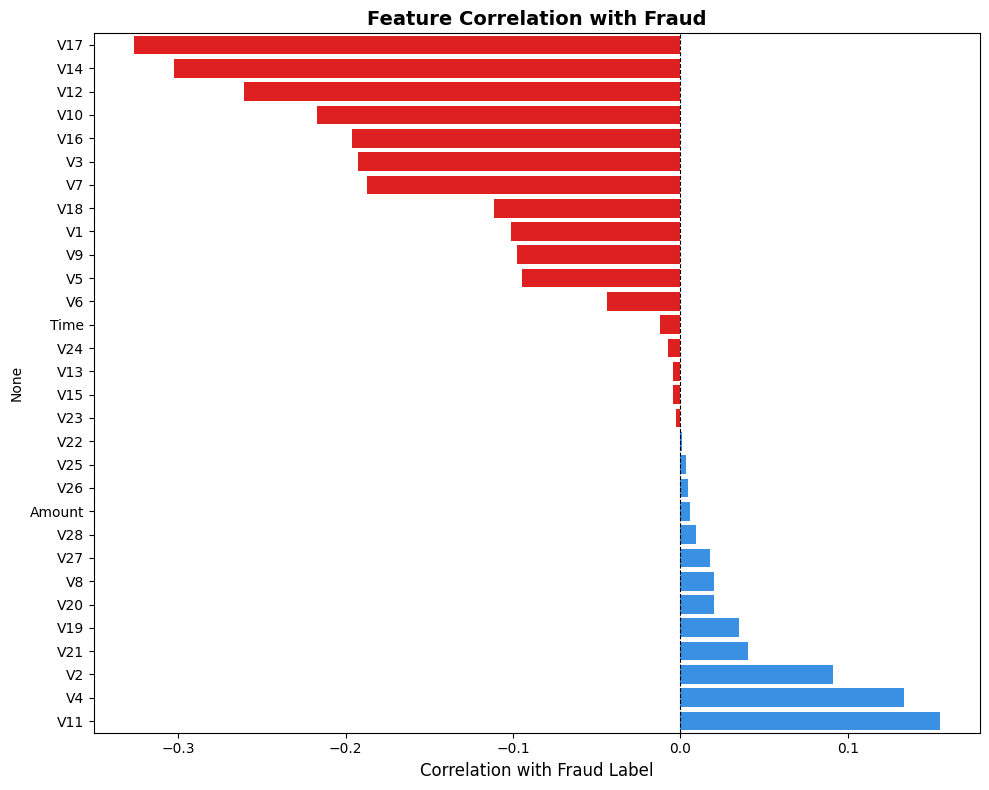

In [19]:
import seaborn as sns

correlations = df.corr()['Class'].drop('Class').sort_values()

colors = []
for c in correlations.values:
    if c < 0:
        colors.append('red')
    else:
        colors.append('#1E90FF')

plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette=colors, hue=correlations.index, legend=False)

plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Correlation with Fraud Label', fontsize=12)
plt.title('Feature Correlation with Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('plots/feature_correlations_with_fraud.png', dpi=150)
plt.show()

We notice that:
- V17 and V14 are the strongest fraud signals. Lower values of these components are strongly correlated with fraud
- Amount has almost no correlation with fraud. This doesn't mean Amount is useless; it's possible that the relationship is non-linear. We already showed in `1.4` that most fraud happens at low amounts, but this correlation isn't shown here due to non-linearity. This is why we use non-linear models like Random Forest, XGBoost, and MLP.

---

## 2. Preprocessing

A few things to note:

1. **Split first, then scale:** Fitting any scaler on data before splitting leaks test set statistics into training. As a result, the model looks better than it actually is. We fit only on training data, then apply to both.

2. **Stratify the split:** Since we have only 492 fraud cases, a random split could produce a test set with very few fraud examples. Therefore stratify in `train_test_split()` guarantees the same fraud ratio in both splits.

3. **RobustScaler over StandardScaler for Amount:** Amount has extreme outliers up to €25,691 against a median of €22. RobustScaler scales using median and IQR, so it remains immune to the outliers. StandardScaler's mean and standard deviation would both be skewed by them.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.loc[:, df.columns != "Class"]  # All features
y = df["Class"]                       # Target (0s and 1s)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)

print(f"Training set: {X_train.shape[0]:,} samples with {y_train.sum()} frauds")
print(f"Test set: {X_test.shape[0]:,} samples with {y_test.sum()} frauds")

Training set: 227,845 samples with 394 frauds
Test set: 56,962 samples with 98 frauds


**Train/Test Split Overview:**

```
Dataset: 284,807 total transactions
│
├── Training set: 227,845 transactions
│   ├── Legitimate: 227,451  (99.83%)
│   └── Fraud: 394            (0.17%)
│
└── Testing set: 56,962 transactions
    ├── Legitimate: 56,864   (99.83%)
    └── Fraud: 98             (0.17%)
```

### 2.1 Scaling Time and Amount

Since V1–V28 PCA-transformed, we only have to scale `Time` and `Amount`.

For `Amount`, we use **RobustScaler()** due to the outliers seen in the histograms above. For `Time`, we'll use RobustScaler as well for consistency, although `StandardScaler()` would work as well since time doesn't have an outlier problem:

In [21]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']]  = scaler.transform(X_test[['Time', 'Amount']])

Let's now see the median and standard deviation after scaling:

In [22]:
scaling_check = pd.DataFrame({
    'Median': [X_train['Time'].median(), X_train['Amount'].median()],
    'Std': [X_train['Time'].std(), X_train['Amount'].std()],
}, index=['Time', 'Amount']).round(2)

display(scaling_check)

,Median,Std
Time,0.0,0.56
Amount,0.0,3.53


We can see that the median is now 0. This is because `RobustScaler()` centers on the median, so the outliers no longer distort the scale.

Now we're ready for the algorithms.

---

## 3. Customer Segmentation: K-Means Clustering

For the first Machine Learning Algorithm, we'll use the K-Means Clustering. Before we even build fraud detectors, we ask ourselves: are there any noticable groups in this data? Through clustering, we can learn about spending patterns and frequent buyers. This would give us an idea what and where the "normal" amount lies in vs the fraud amounts.

K-Means works by minimizing the total squared distance from each point to its cluster centroid. There are 2 things to note:

- **K:** The number of clusters. We'll use the Elbow Method and Silhouette Score to determine the best K value.
- **Scaled features:** K-Means uses Euclidean distance, so unscaled features dominate the calculation. Our data is already scaled, so this is good.

### 3.1 Finding the best K value using the Elbow Method + Silhouette Score

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_numbers = [i for i in range(2, 11)]
inertia = []
silhouette_scores = []

for k in cluster_numbers:
    kmeans = KMeans(n_clusters=k, random_state=99)
    labels = kmeans.fit_predict(X_train)
    inertia.append(kmeans.inertia_)

    silhouette_average = silhouette_score(X_train, labels, sample_size=20000)
    silhouette_scores.append(silhouette_average)

best_k = cluster_numbers[silhouette_scores.index(max(silhouette_scores))]
print(f"Best K from the silhouette score: {best_k}")

Best K from the silhouette score: 2


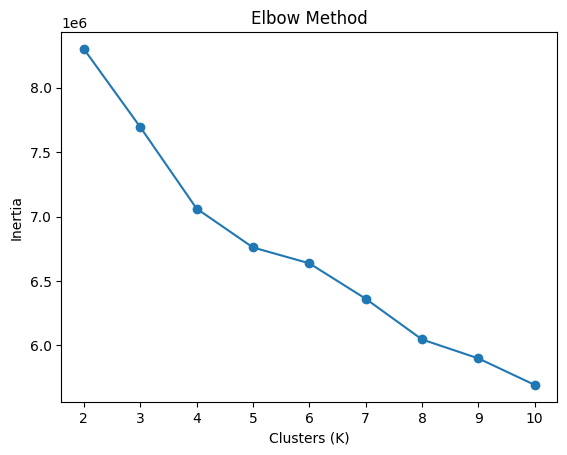

In [24]:
plt.plot(cluster_numbers, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters (K)")
plt.ylabel("Inertia")
# plt.savefig('plots/elbow_method.png', dpi=200)
plt.show()

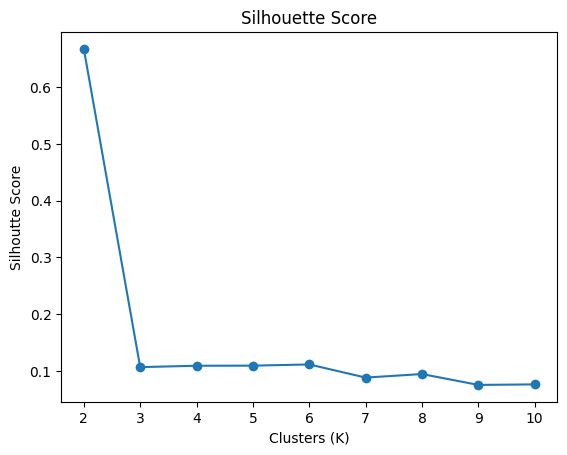

In [25]:
plt.plot(cluster_numbers, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Clusters (K)")
plt.ylabel("Silhoutte Score")
# plt.savefig('plots/silhouette_score.png', dpi=200)
plt.show()

We can see that the silhouette score has a peak at K=2 and then drops
drops. The elbow curve shows no clear bend. When the two methods differ, silhouette score is the more reliable indicator, so we proceed with K=2.

It also makes sense since in this context, we're working with typical behavior vs atypical behavior.

### 3.2 Fitting K-Means Model

We picked K=2 as the best amount of clusters due to a high silhouette score, so cluster separation is strongest at this K. Let's fit the model into the training data:

In [26]:
kmeans = KMeans(n_clusters=2, random_state=99)
train_clusters = kmeans.fit_predict(X_train)
test_clusters = kmeans.predict(X_test)

print(f"From the training set of {len(train_clusters)} transactions:\n")
unique, counts = np.unique(train_clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} transactions ({count/len(train_clusters)*100:.2f}%)")

From the training set of 227845 transactions:

Cluster 0: 4328 transactions (1.90%)
Cluster 1: 223517 transactions (98.10%)


We can see that K-Means identified two clusters without ever being told which transactions were legitimate or fraudulent. This is fully unsupervised.

- Cluster 0 contains 1.9% of transactions, which mirrors the 0.17% fraud rate in the dataset. This small cluster captured irregular activity and the model was able to naturally isolate this minority.

- Similarly, cluster 1 contains 98.1% of transactions, mirring the 99.83% of legitimate transactions.

This makes sense, especially with our choice of K=2 that we are separating typical and atypical behavior. We'll confirm this in the cluster profile and PCA visualization next.

### 3.3 Cluster Examination

Given the clusters we found, we know that they aren't 100% accurate and that there are False Positives and False Negatives. Let's examine what each cluster looks like in terms of the fraud concentration:

In [27]:
df_train = X_train.copy()
df_train['Cluster'] = train_clusters
df_train['Class'] = y_train.values

profile = df_train.groupby('Cluster').agg(Transaction_Count=('Class', 'count'), Fraud_Count=('Class', 'sum'), Fraud_Rate=('Class', 'mean'),).round(4)
profile['Fraud_Rate'] = (profile['Fraud_Rate'] * 100).round(3)

display(profile)

,Transaction_Count,Fraud_Count,Fraud_Rate
Cluster,,,
0,4328,17,0.39
1,223517,377,0.17


We can see that Cluster 0 is the high risk group. Despite having 1.9% of transactions, it has a fraud rate more than double of Cluster 1. In here, transactions are small in amount, which is what we saw in the Data Analysis portion where most fraudulent transactions happen in smaller amounts.

Cluster 1 has the normal spending behavior with a much lower fraud concentration.

### 3.4 Visualizing Clusters with PCA

This K-Means clustering ran in 30 dimensions. In order to visualize it, let's project it down to 2D using PCA just for display. The clustering was done on the full feature set.

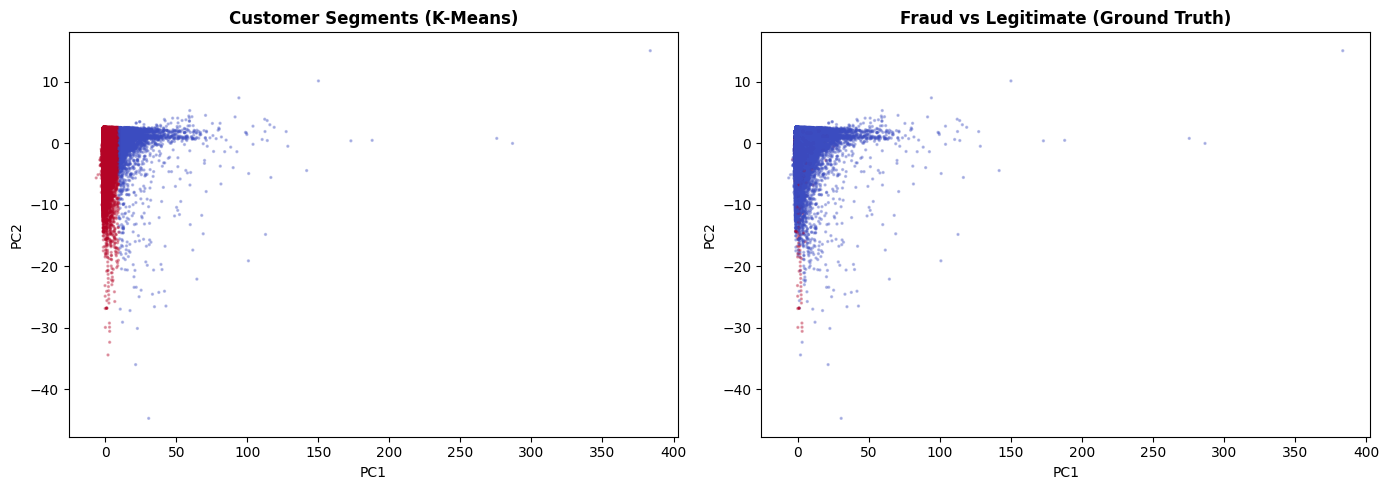

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=100)
X_2d = pca.fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=train_clusters, cmap='coolwarm', s=2, alpha=0.3)
axes[0].set_title('Customer Segments (K-Means)', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_train.values, cmap='coolwarm', s=2, alpha=0.3)
axes[1].set_title('Fraud vs Legitimate (Ground Truth)', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
# plt.savefig('plots/pca_clusters.png', dpi=150)
plt.show()

The left chart shows the 2 clusters K-Means found purely from transaction patterns with no fraud labels involved. The right chart shows the actual fraud labels on the exact same projection. 

2 things stand out:

- The red regions are somewhat between both charts. Cluster 0 (left) sits in nearly the same location as the fraud points (right). K-Means naturally isolated the transactions that are fraudulent without ever being told which ones were fraud. 
- The majority of points spread to the right in blue are normal spendings and is clearly separated from the anomalous cluster.

---

## 4. Handling Imbalance using SMOTE

Currently the dataset is 99.83% legitimate transactions. If we train a model without addressing this, it will predict legitimate for everything and achieve 99.83% accuracy while catching zero fraud.

Therefore, we will use **SMOTE (Synthetic Minority Oversampling Technique)** on the training set. SMOTE doesn't duplicate existing data; it creates new ones by linear interpolation between a fraud point and its nearest fraud neighbors. This gives the model more data to learn from.

**Important:** SMOTE is applied only to training data. The test set stays original. If you apply SMOTE before splitting, synthetic fraud samples leak into the test set and the  evaluation becomes meaningless.

In [29]:
from imblearn.over_sampling import SMOTE
from collections import Counter

before = Counter(y_train)
smote  = SMOTE(sampling_strategy=0.1, random_state=99)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
after  = Counter(y_train_sm)
after_ratio = after[0] // after[1]

smote_summary = pd.DataFrame({
    'Legitimate': [before[0], after[0]],
    'Fraud': [before[1], after[1]],
    'Total': [before[0] + before[1], after[0] + after[1]],
    'Ratio': [f"{before[0]//before[1]}:1", f"{after_ratio}:1"],
}, index=['Before SMOTE', 'After SMOTE'])

display(smote_summary)

,Legitimate,Fraud,Total,Ratio
Before SMOTE,227451,394,227845,577:1
After SMOTE,227451,22745,250196,10:1


Rather than fully balancing to 1:1, we use a moderate `sampling_strategy=0.1`. This brings fraud to 10% of legitimate transactions instead of 100%. This is intentional since a full 1:1 balance means 99.8% of fraud training samples would be synthetic. This would risk the model learning SMOTE's interpolations rather than the real fraud patterns. The test set remains at its original 577:1 ratio.

---

```
Stage 1 (Baseline)          Stage 2 (Deep Learning)
─────────────────           ──────────────────────
Logistic Regression    →    Multi-Layer Perceptron
Random Forest          →    (PyTorch)
XGBoost
```

## 5. Stage 1 — Baseline Models

Before using deep learning, let's get baselines. Why? A simple model that performs well is more preferable than a complex one that performs equally well.

We evaluate both models with Precision, Recall, F1-Score, and ROC-AUC, not accuracy.

Our main metric is Recall. A missed fraud transaction has a direct financial cost. A false alarm means an inconvenient phone call to a customer. They are not equivalent.

### 5.1 Logistic Regression

A logistic regression is a linear model that predicts the probability of fraud using a sigmoid function. We will use `class_weight='balanced'` as a secondary guard against imbalance on top of SMOTE.

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score)

lr = LogisticRegression(class_weight='balanced', C=1.0, max_iter=1000, random_state=99)

lr.fit(X_train_sm, y_train_sm)
lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, lr_pred, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.96      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.97      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9895


Let's save the metrics in a dictionary to compare later:

In [95]:
lr_metrics_comparison = {'Model': 'Logistic Regression', 'Precision': precision_score(y_test, lr_pred), 'Recall': recall_score(y_test, lr_pred), 'F1-Score': f1_score(y_test, lr_pred), 'ROC-AUC': roc_auc_score(y_test, lr_proba),}

We will use the following function to plot the confusion matrix:

In [96]:
def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Predicted Legit', 'Predicted Fraud'], yticklabels=['Actual Legit', 'Actual Fraud'], ax=ax)
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

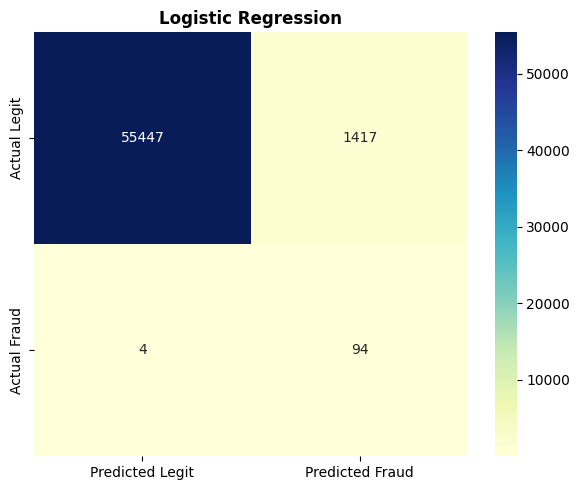

True Positives (fraud caught): 94
False (fraud missed): 4
False (false alarms): 1417
True Negatives (legit correctly): 55447


In [97]:
cm = confusion_matrix(y_test, lr_pred)
plot_confusion_matrix(cm, 'Logistic Regression')

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (fraud caught): {tp}")
print(f"False (fraud missed): {fn}")
print(f"False (false alarms): {fp}")
print(f"True Negatives (legit correctly): {tn}")

Looks like Logistic Regression caught 94 out of 98 fraud cases, which is a strong recall. The cost is 1417 false alarms, which is high but expected given we prioritized catching fraud over precision. This sets the benchmark for Random Forest and XGBoost need to beat.

### 5.2 Random Forest

A Random Forest combines many decision trees where each tree is trained on a random sample of the data and uses random features when making splits. This makes the trees different from each other. As a result, their mistakes balance out.

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=99)

rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC:  {roc_auc_score(y_test, rf_proba):.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.90      0.81      0.85        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC:  0.9926


Let's save the metrics in a dictionary to compare later:

In [34]:
rf_metrics_comparison = {'Model': 'Random Forest', 'Precision': precision_score(y_test, rf_pred), 'Recall': recall_score(y_test, rf_pred), 'F1-Score': f1_score(y_test, rf_pred), 'ROC-AUC': roc_auc_score(y_test, rf_proba),}

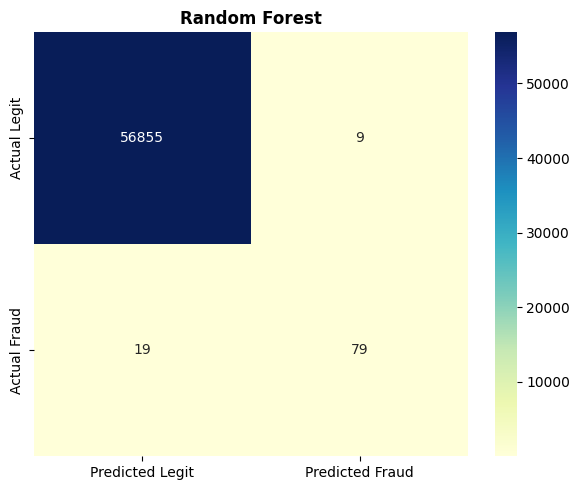

True Positives (fraud caught): 79
False (fraud missed): 19
False (false alarms): 9
True Negatives (legit correctly): 56855


In [100]:
cm_rf = confusion_matrix(y_test, rf_pred)
plot_confusion_matrix(cm_rf, 'Random Forest')

tn, fp, fn, tp = cm_rf.ravel()
print(f"True Positives (fraud caught): {tp}")
print(f"False (fraud missed): {fn}")
print(f"False (false alarms): {fp}")
print(f"True Negatives (legit correctly): {tn}")

Random Forest was much better at avoiding false alarms. It only made 9 false positives, whereas Logistic Regression made 1417, so Random Forest had much better precision. However, the trade-off is that Random Forest missed more fraud cases: 18 missed frauds compared to 4 for Logistic Regression. This means Random Forest is more careful when predicting fraud.

The trade-off is:
- Random Forest = fewer false alarms, but misses more fraud
- Logistic Regression = catches more fraud, but creates many more false alarms

### 5.3 XGBoost - Gradient Boosting

Random Forest builds trees independently and then averages them. However, XGBoost builds trees sequentially where each new tree focuses on correcting the mistakes of all previous trees.

This usually outperforms Random Forests, so I included this as the third model:

In [36]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='aucpr', random_state=99)
xgb_model.fit(X_train_sm, y_train_sm)
xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9886


In [37]:
xgb_metrics = {'Model': 'XGBoost', 'Precision': precision_score(y_test, xgb_pred), 'Recall': recall_score(y_test, xgb_pred), 'F1-Score': f1_score(y_test, xgb_pred), 'ROC-AUC': roc_auc_score(y_test, xgb_proba),}

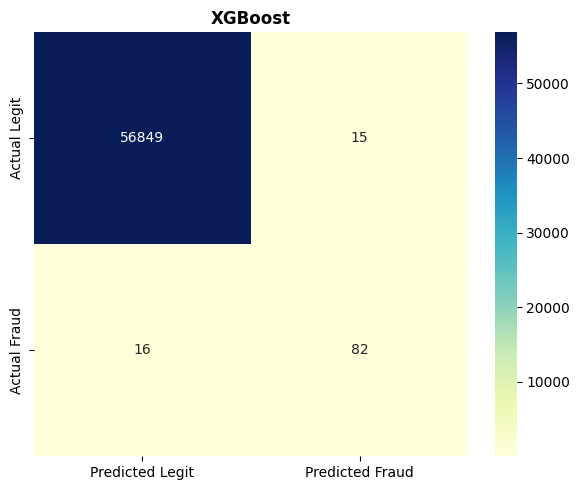

True Positives (fraud caught): 82
False (fraud missed): 16
False (false alarms): 15
True Negatives (legit correctly): 56849


In [101]:
cm_xgb = confusion_matrix(y_test, xgb_pred)
plot_confusion_matrix(cm_xgb, 'XGBoost')

tn, fp, fn, tp = cm_xgb.ravel()
print(f"True Positives (fraud caught): {tp}")
print(f"False (fraud missed): {fn}")
print(f"False (false alarms): {fp}")
print(f"True Negatives (legit correctly): {tn}")

XGBoost gave the best balance so far. It caught 82 fraud cases with 15 false alarms. Compared to Logistic Regression, it reduced false alarms from 1,417 to 15. Compared to Random Forest, it caught 2 more fraud cases while only adding 6 more false alarms. Overall, XGBoost performs well because it learns from previous mistakes and improves step by step.

### 5.5 Cost-Sensitive Analysis

Every evaluation metric so far was unitless. It tells us the model is good, but not what "good" costs the business.
 
We will now reframe the threshold problem in dollar terms:
 
| Outcome | Cost |
|---------|------|
| True Positive (fraud caught) | $0 — transaction reversed |
| True Negative (legit approved) | $0 — normal |
| False Negative (fraud missed) | Full transaction amount lost |
| False Positive (false alarm) | $10 — analyst investigation |

These are stated assumptions. In production, the finance team provides the real numbers. We run this analysis on XGBoost first, then on Random Forest (our recommended model) to confirm the business case for deployment.

In [ ]:
amounts_test = scaler.inverse_transform(X_test[['Time', 'Amount']])[:, 1]
thresholds = np.arange(0.05, 0.95, 0.01)
costs = []

for threshold in thresholds:
    y_pred_t = (xgb_proba >= threshold).astype(int)
    missed_fraud = (y_test == 1) & (y_pred_t == 0)
    missed_fraud_cost = amounts_test[missed_fraud].sum()
    false_alarms = (y_test == 0) & (y_pred_t == 1)
    false_alarm_cost = false_alarms.sum() * 10
    costs.append({'threshold': round(threshold, 2), 'total_cost': missed_fraud_cost + false_alarm_cost})

df_costs = pd.DataFrame(costs)
optimal  = df_costs.loc[df_costs['total_cost'].idxmin()]

print(f"Optimal threshold: {optimal['threshold']}")
print(f"Minimum total cost: ${optimal['total_cost']:.2f}")
print(f"Default (0.5) cost: ${df_costs[df_costs['threshold']==0.50]['total_cost'].values[0]:.2f}")

Optimal threshold: 0.1
Minimum total cost: $559.72
Default (0.5) cost: $2278.99


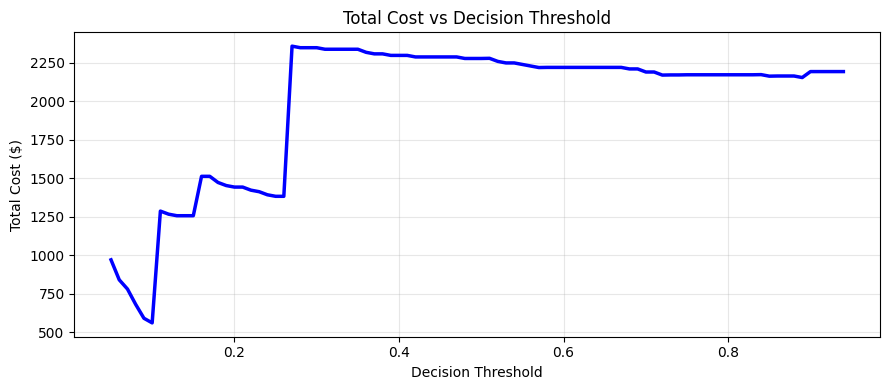

In [40]:
plt.figure(figsize=(9, 4))
plt.plot(df_costs['threshold'], df_costs['total_cost'], linewidth=2.5, color='blue')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Cost ($)')
plt.title('Total Cost vs Decision Threshold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('plots/cost_analysis.png', dpi=150)
plt.show()

We can see that the best threshold is 0.1 since this is where the total cost is lowest. At the default threshold of 0.5, the model is too careful and misses a lot of fraud cases, which raises the total cost to $2,278. When the threshold is lowered to 0.1, the model flags more transactions as fraud, which lowers the total cost to $559. This saves $1,719. This shows the real dollar impact of choosing a better threshold.

### 5.6 Cost-Sensitive Analysis on Random Forest

Since Random Forest is our recommended model, we repeat the cost analysis on its probability outputs. This gives us the actual business cost figures for the model we are recommending for deployment.

In [90]:
costs_rf = []
for threshold in thresholds:
    y_pred_t = (rf_proba >= threshold).astype(int)
    missed_fraud      = (y_test == 1) & (y_pred_t == 0)
    missed_fraud_cost = amounts_test[missed_fraud].sum()
    false_alarms      = (y_test == 0) & (y_pred_t == 1)
    false_alarm_cost  = false_alarms.sum() * 10
    costs_rf.append({'threshold': round(threshold, 2), 'total_cost': missed_fraud_cost + false_alarm_cost})

df_costs_rf = pd.DataFrame(costs_rf)
optimal_rf  = df_costs_rf.loc[df_costs_rf['total_cost'].idxmin()]
default_rf  = df_costs_rf[df_costs_rf['threshold'] == 0.50]['total_cost'].values[0]

print(f"Optimal threshold:  {optimal_rf['threshold']}")
print(f"Minimum total cost: ${optimal_rf['total_cost']:.2f}")
print(f"Default (0.5) cost: ${default_rf:.2f}")
print(f"Savings vs default: ${default_rf - optimal_rf['total_cost']:.2f}")

Optimal threshold:  0.57
Minimum total cost: $1207.72
Default (0.5) cost: $1226.72
Savings vs default: $19.00


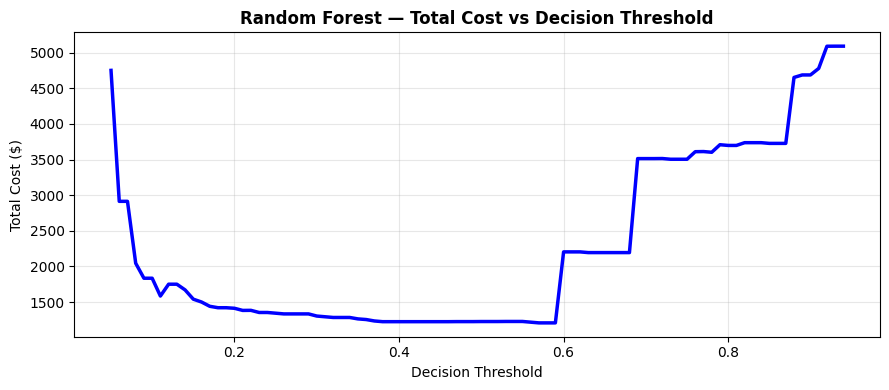

In [91]:
plt.figure(figsize=(9, 4))
plt.plot(df_costs_rf['threshold'], df_costs_rf['total_cost'], linewidth=2.5, color='blue')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Cost ($)')
plt.title('Random Forest — Total Cost vs Decision Threshold', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('plots/cost_analysis_rf.png', dpi=150)
plt.show()

Random Forest’s best threshold is 0.57, which is very close to the default threshold of 0.5. Changing the threshold only saved $19, meaning that the default threshold was already working well. This is very different from XGBoost, where changing the threshold saved $1719. Random Forest already makes strong decisions without much adjustment because it has high precision and does not create many false alarms. This makes it more favorable to deploy than XGBoost since doesn't need major threshold tuning.

## 6. Stage 2 — Multi-Layer Perceptron with PyTorch

The Stage 1 models are fast but limited. Logistic Regression is linear. Random Forest and XGBoost use tree-based boundaries. A neural network can learn arbitrary non-linear patterns  that tree models miss.

### 6.1 Defining the Model

We will define a three-layer MLP. Each hidden layer is followed by ReLU activation and Dropout to prevent overfitting. The output is a raw logit and sigmoid is applied inside BCEWithLogitsLoss for numerical stability:

In [67]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class FraudMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim):
        super().__init__()
        self.layer1  = nn.Linear(input_dim, hidden_dim1)
        self.layer2  = nn.Linear(hidden_dim1, hidden_dim2)
        self.layer3  = nn.Linear(hidden_dim2, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer3(x)
        return x

model = FraudMLP(X_train_sm.shape[1], 64, 32, 1).to(device)

print("\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda

Model Architecture:
FraudMLP(
  (layer1): Linear(in_features=30, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters: 4,097


### 6.2 Preparing the data

PyTorch requires tensors, not DataFrames. Therefore, we will convert everything and wrap the training data in a DataLoader which feeds it in batches of 256 rather than all at once. We also set `pos_weight` to tell the loss function that fraud mistakes are more costly:

In [68]:
X_train_t = torch.from_numpy(X_train_sm.values).float().to(device)
y_train_t = torch.from_numpy(y_train_sm.values).float().reshape(-1, 1).to(device)
X_test_t  = torch.from_numpy(X_test.values).float().to(device)
y_test_t  = torch.from_numpy(y_test.values).float().reshape(-1, 1).to(device)

loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

num_legit  = (y_train_sm == 0).sum()
num_fraud  = (y_train_sm == 1).sum()
pos_weight = torch.tensor([num_legit / num_fraud]).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Let's get some info in the training batches per epoch and the penalty:

In [69]:
print(f"Training batches per epoch: {len(loader)}")
print(f"pos_weight (fraud penalty): {pos_weight.item():.2f}")

Training batches per epoch: 978
pos_weight (fraud penalty): 10.00


### 6.3 Training Loop

For each epoch we will loop through every batch, compute the loss, and update the weights via backpropagation. We will also track test loss each epoch:

In [70]:
epochs = 20
train_losses = []
test_losses  = []

for epoch in range(epochs + 1):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in loader:
        y_pred = model(X_batch)  # Forward prop
        loss = loss_fn(y_pred, y_batch)  # Loss

        optimizer.zero_grad()
        loss.backward()  # Back prop
        optimizer.step()  # Gradient descent

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(loader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        test_loss = loss_fn(model(X_test_t), y_test_t).item()
        test_losses.append(test_loss)

    if epoch % 5 == 0:
        print(f"Epoch {epoch}/{epochs}  |  Train Loss: {avg_train_loss:.4f}  |  Test Loss: {test_loss:.4f}")

Epoch 0/20  |  Train Loss: 0.5521  |  Test Loss: 0.1382
Epoch 5/20  |  Train Loss: 0.1449  |  Test Loss: 0.0568
Epoch 10/20  |  Train Loss: 0.0946  |  Test Loss: 0.0396
Epoch 15/20  |  Train Loss: 0.0622  |  Test Loss: 0.0320
Epoch 20/20  |  Train Loss: 0.0450  |  Test Loss: 0.0284


### 6.4 Loss Curve

A decreasing train and test loss that stay close together means the
model is learning without overfitting.

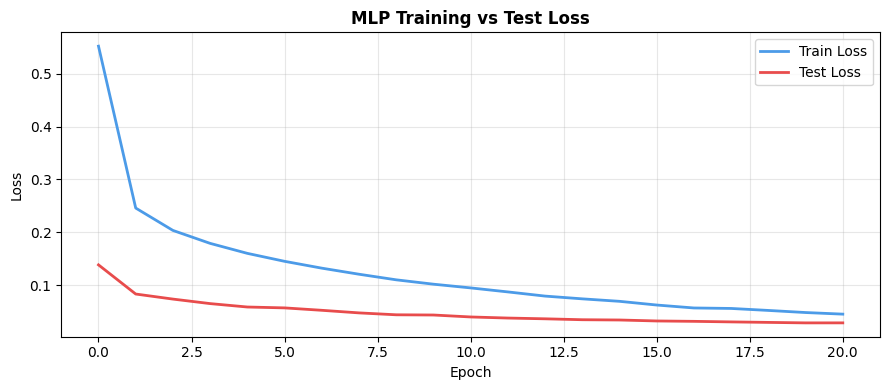

In [71]:
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss', linewidth=2, color='#4C9BE8')
plt.plot(test_losses,  label='Test Loss',  linewidth=2, color='#E84C4C')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Training vs Test Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('plots/mlp_loss.png', dpi=150)
plt.show()

### 6.5 Evaluation

We switch to `model.eval()` to turn off dropout, run the test set through, apply sigmoid to convert logits to probabilities, then apply the 0.5 threshold to get final predictions.

In [72]:
model.eval()
with torch.no_grad():
    mlp_proba = torch.sigmoid(model(X_test_t)).cpu().numpy().flatten()

mlp_pred = (mlp_proba > 0.5).astype(int)

print(classification_report(y_test, mlp_pred, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, mlp_proba):.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56864
       Fraud       0.22      0.94      0.35        98

    accuracy                           0.99     56962
   macro avg       0.61      0.97      0.67     56962
weighted avg       1.00      0.99      1.00     56962

ROC-AUC: 0.9849


In [76]:
mlp_metrics = {'Model': 'MLP (PyTorch)', 'Precision': precision_score(y_test, mlp_pred), 'Recall': recall_score(y_test, mlp_pred), 'F1-Score': f1_score(y_test, mlp_pred), 'ROC-AUC': roc_auc_score(y_test, mlp_proba)}

### 6.6 Confusion Matrix

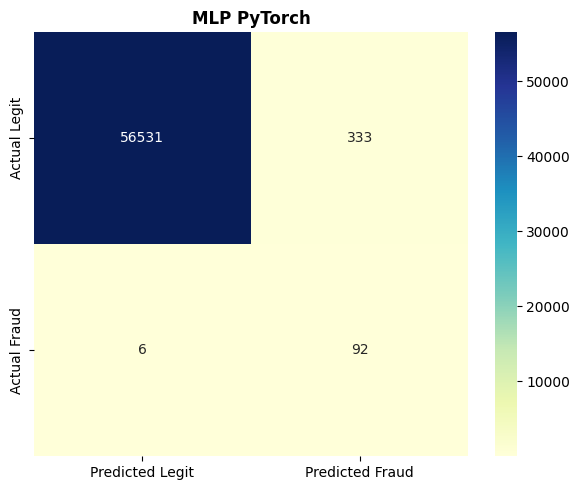

In [102]:
cm_mlp = confusion_matrix(y_test, mlp_pred)
plot_confusion_matrix(cm_mlp, 'MLP PyTorch')

Looks like the MLP caught 92 out of 98 fraud cases, but it also created 333 false alarms. Compared to the earlier models, it performs somewhere in between Logistic Regression and Random Forest. It catches a lot of fraud like Logistic Regression, but with fewer false alarms, while Random Forest is more careful but misses slightly more fraud. The neural network is more complex, but it does not beat the tree-based models. This means that models like Random Forest and XGBoost already capture the fraud patterns well, so a neural network may not be necessary.

---

## 7. Model Comparison & Final Recommendation

All four models trained on the same data, evaluated on the same untouched test set. Let's have a recap:

### Comparison Table

In [84]:
results = [lr_metrics_comparison, rf_metrics_comparison, xgb_metrics, mlp_metrics]

df_results = pd.DataFrame(results).set_index('Model').round(4)

display(df_results.style.highlight_max(axis=0, color="#fbffee"))

,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.062200,0.959200,0.116800,0.989500
Random Forest,0.897700,0.806100,0.849500,0.992600
XGBoost,0.845400,0.836700,0.841000,0.988600
MLP (PyTorch),0.216500,0.938800,0.351800,0.984900


### Confusion Matrices side by side

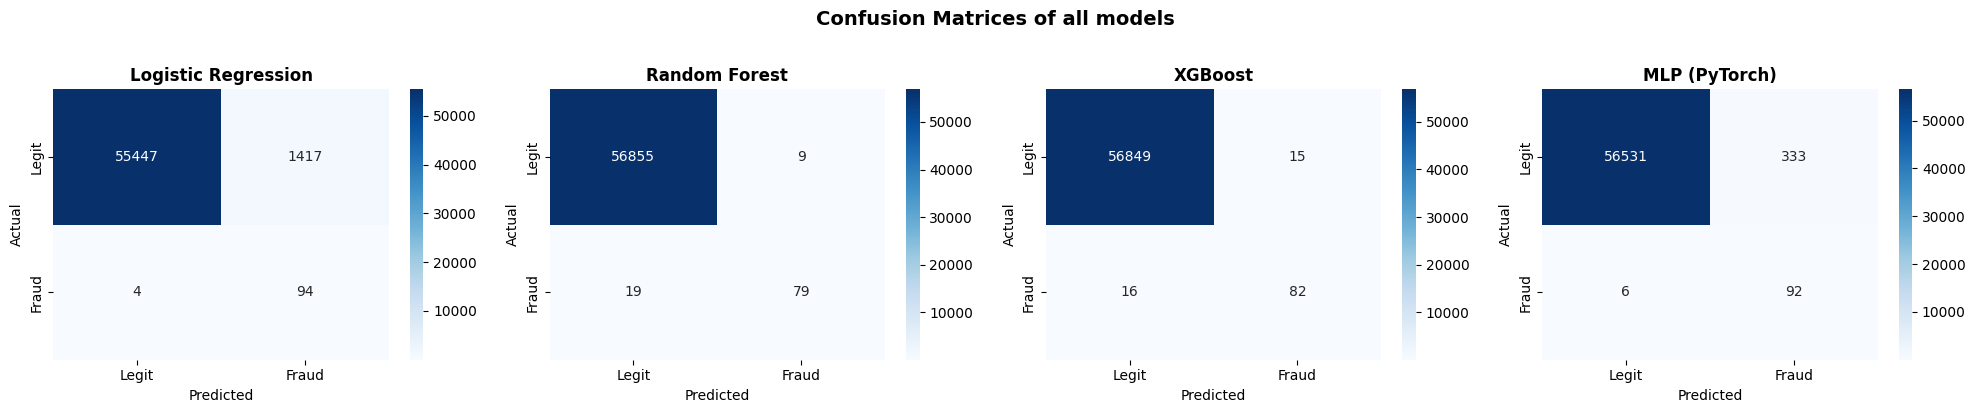

In [89]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, cm_data, title in zip(axes, [cm, cm_rf, cm_xgb, cm_mlp], ['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP (PyTorch)']):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices of all models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Final Recommendation: Random Forest

Based on all four models evaluated on the same untouched test set, Random Forest is the recommended model for deployment.

Let's look at the accuracies:

| Model | Fraud Caught | False Alarms | F1 | ROC-AUC |
|-------|-------------|--------------|-----|---------|
| Logistic Regression | 94/98 | 1,417 | 0.12 | 0.9895 |
| **Random Forest** | **79/98** | **9** | **0.85** | **0.9926** |
| XGBoost | 82/98 | 15 | 0.84 | 0.9886 |
| MLP (PyTorch) | 92/98 | 333 | 0.35 | 0.9849 |

**Why Random Forest:**
Random Forest achieves the highest F1-score (0.85) and the highest ROC-AUC (0.9926) of all four models, and only 9 false alarms (highest of the 4). It has the most balance between catching fraud and not overwhelming with false positives.

The cost-sensitive analysis confirms that Random Forest's optimal threshold of 0.57 is very close to the default 0.5, meaning the model is already calibrated. No significant threshold tuning is needed for deployment.

**Why not the others:**
Logistic Regression's 1,417 false alarms make it impossible. XGBoost catches 3 more fraud cases but at the cost of 6 more false alarms and a lower F1 and ROC-AUC. The MLP's 333 false alarms and 0.22 precision, despite strong recall, makes it not practical.

**Further considerations:**
- Deploy at threshold 0.57 rather than the default 0.5 as shown from the cost-sensitive analysis
- Retrain often as fraud patterns evolve over time
- Monitor precision and recall on live data to detect model drift